# Week 2: Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The opposite of hot is'
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 6697, 286, 3024, 318]
  pos 0: id    464 -> 'The'
  pos 1: id   6697 -> ' opposite'
  pos 2: id    286 -> ' of'
  pos 3: id   3024 -> ' hot'
  pos 4: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (5, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.526
  ' opposite'  0.199
  ' of'        0.083
  ' hot'       0.124
  ' is'        0.068

logits shape (batch, seq, vocab): (1, 5, 50257)
top 10 next tokens:
  ' the'         0.1550
  ' that'        0.0539
  ' a'           0.0535
  ' not'         0.0333
  ' to'          0.0325
  ' also'        0.0158
  ' actually'    0.0150
  ' hot'         0.0148
  ' always'      0.0108
  ' in'          0.0103


### Part 1 analysis
The top 10 next token are mostly common words like "the", "that", "a", and "to".  The obvious best choice, "cold", is not in the top 10.  The model is not solving the semantic challenge for this example and is instead choosing high-frequency functional words.  

I would not consider this a failure case.  It is a limitation of the model.

## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

In [3]:
# Helper function to plot the top N token probabilities for one or more distributions
def plot_top_tokens(dists, titles, num_bars=15):
    fig, axes = plt.subplots(1, len(dists), figsize=(13 * len(dists) / 3, 3), sharey=True)
    for ax, dist, title in zip(axes, dists, titles):
        ax.bar(range(num_bars), np.sort(dist)[::-1][:num_bars], color='#1d4ed8')
        ax.set_title(title)
    plt.tight_layout(); plt.show()

In [4]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())

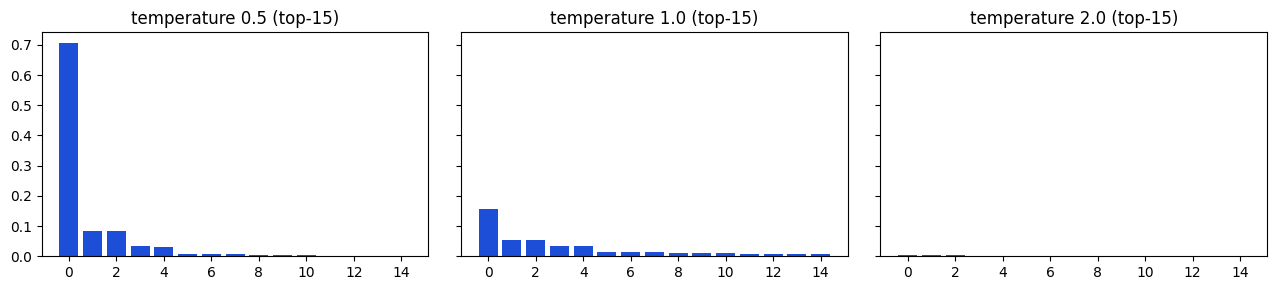

top token prob: temp 0.5 = 0.706, temp 1.0 = 0.155, temp 2.0 = 0.005
temperature 0.5: top token has a 70.6% chance; distribution behaves like choosing among about 4 realistic options
temperature 1.0: top token has a 15.5% chance; distribution behaves like choosing among about 371 realistic options
temperature 2.0: top token has a 0.5% chance; distribution behaves like choosing among about 20651 realistic options


In [5]:
base = softmax(z)
temps = [0.5, 1.0, 2.0]

# Show the top-15 tokens for each temperature setting
distributions = [temperature(z, t) for t in temps]
titles = [f'temperature {t} (top-15)' for t in temps]
plot_top_tokens(distributions, titles)

print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

# Plain language explanation of what each temperature setting did to the distribution
for t, dist in zip(temps, distributions):
    top_prob = dist.max()                    # chance the single most likely token gets picked
    effective_choices = np.exp(entropy(dist)) # how many realistic options the distribution behaves like
    print(f'temperature {t}: top token has a {top_prob:.1%} chance; '
          f'distribution behaves like choosing among about {effective_choices:.0f} realistic options')

### Top-k

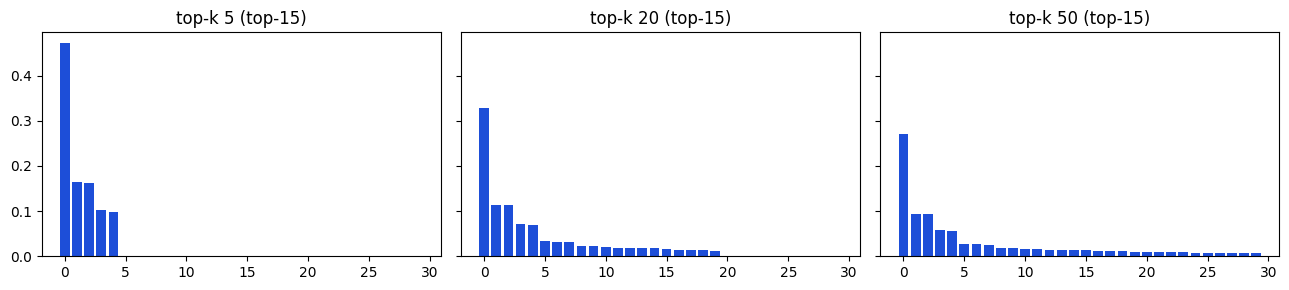

top token prob: k=5 = 0.472, k=20 = 0.328, k=50 = 0.271
top-k 5: only the 5 most likely tokens are allowed; top one has a 47.2% chance; only about 4 tokens of the 5 allowed are realistically competing for the pick
top-k 20: only the 20 most likely tokens are allowed; top one has a 32.8% chance; only about 11 tokens of the 20 allowed are realistically competing for the pick
top-k 50: only the 50 most likely tokens are allowed; top one has a 27.1% chance; only about 21 tokens of the 50 allowed are realistically competing for the pick


In [6]:
ks = [5, 20, 50]
distributions = [top_k(base, k) for k in ks]
titles = [f'top-k {k} (top-15)' for k in ks]
plot_top_tokens(distributions, titles, num_bars=30)

print('top token prob: k=%d = %.3f, k=%d = %.3f, k=%d = %.3f' % (
    ks[0], top_k(base, ks[0]).max(), ks[1], top_k(base, ks[1]).max(), ks[2], top_k(base, ks[2]).max()))

# Plain language explanation of Top k's effect on the distributions
for k, dist in zip(ks, distributions):
    top_prob = dist.max()
    effective_choices = np.exp(entropy(dist))
    print(f'top-k {k}: only the {k} most likely tokens are allowed; top one has a {top_prob:.1%} chance; '
          f'only about {effective_choices:.0f} tokens of the {k} allowed are realistically competing for the pick')

### Top-p

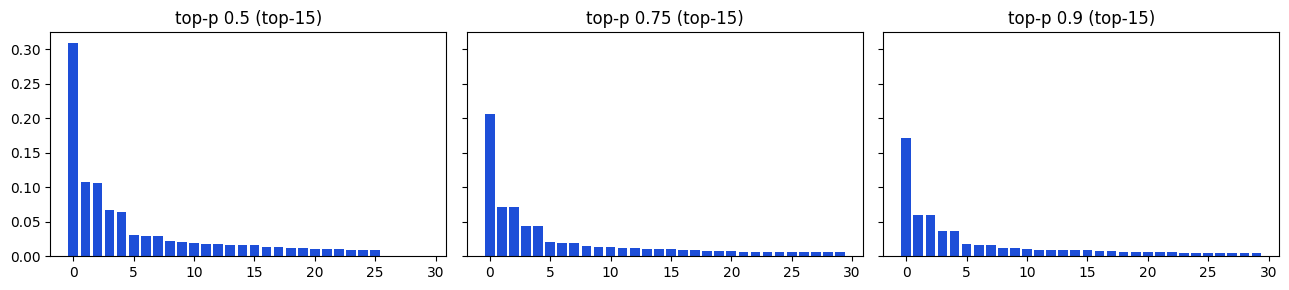

nucleus size: p=0.50 kept 26, p=0.75 kept 325, p=0.90 kept 2296
top-p 0.5: kept the 26 tokens whose probabilities add up to 50%; top one has a 30.9% chance; only about 13 tokens are realistically competing for the pick
top-p 0.75: kept the 325 tokens whose probabilities add up to 75%; top one has a 20.7% chance; only about 64 tokens are realistically competing for the pick
top-p 0.9: kept the 2296 tokens whose probabilities add up to 90%; top one has a 17.2% chance; only about 172 tokens are realistically competing for the pick


In [7]:
ps = [0.5, 0.75, 0.90]
results = [top_p(base, p) for p in ps]   # each entry is (distribution, number_of_tokens_kept)
distributions = [dist for dist, kept in results]
titles = [f'top-p {p} (top-15)' for p in ps]
plot_top_tokens(distributions, titles, num_bars=30)

print('nucleus size: p=%.2f kept %d, p=%.2f kept %d, p=%.2f kept %d' % (
    ps[0], top_p(base, ps[0])[1], ps[1], top_p(base, ps[1])[1], ps[2], top_p(base, ps[2])[1]))

# Plain language explanation of Top p's effect on the distributions
for p, (dist, kept) in zip(ps, results):
    top_prob = dist.max()
    effective_choices = np.exp(entropy(dist))
    print(f'top-p {p}: kept the {kept} tokens whose probabilities add up to {p:.0%}; '
          f'top one has a {top_prob:.1%} chance; only about {effective_choices:.0f} tokens are realistically competing for the pick')

### Combinations

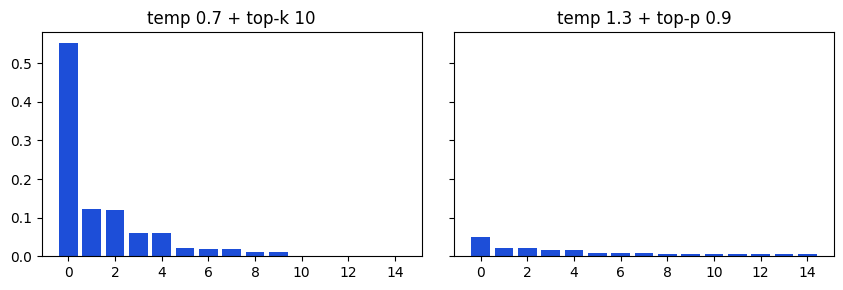

temp 0.7 + top-k 10: top token has a 55.2% chance; behaves like about 5 realistic options
temp 1.3 + top-p 0.9: top token has a 5.0% chance; behaves like about 2045 realistic options


In [8]:
combos = [('temp 0.7 + top-k 10', top_k(temperature(z, 0.7), 10)),
          ('temp 1.3 + top-p 0.9', top_p(temperature(z, 1.3), 0.9)[0])]
plot_top_tokens([dist for _, dist in combos], [title for title, _ in combos])

for label, dist in combos:
    top_prob = dist.max()
    effective_choices = np.exp(entropy(dist))
    print(f'{label}: top token has a {top_prob:.1%} chance; behaves like about {effective_choices:.0f} realistic options')

### Part 2 analysis
I used entropy to examine the results so I could understand them better.  Entropy tells us how spread out the model's guesses are.  Running it through `np.exp()` shows roughly how many tokens the model is seriously considering.  This works because a perfectly uniform distribution over N outcomes has entropy exactly equal to log(N) — so exponentiating undoes the log and recovers N. When the distribution isn't perfectly even, which is the normal case here, the result comes out lower than the total number of tokens, because leaning heavily toward one token means less real uncertainty than spreading equally across all of them.  So this number reflects how many tokens are genuinely competing, not just how many are technically possible.

I added these calculations as printed output below each graph for Part 2.


## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

### Predictions

1) For a temperature of 0.2, I am expecting only the top 1 token to be realistically considered.  My guess is it will have 95% probability.  In part 2 a temperature of 0.5 gave the top token a 70% chance, which seems high to me.  Lowering the temperature even further will cause the top token to almost certainly be chosen.

2) For temperature of 0.9 and top-k of 15, I am expecting the top token to have a small advantage and the rest of the tokens to have a roughly equal chance of being chosen.  In part 2, a temperature of 1.0 resulted in the top token only having a 15% chance of being chosen.  So my guess is a nearly uniform distribution among the top 15 options.

3) For temperature of 1.1 and top-p of 0.6, my guess is there will be 150 tokens kept.  Top-p of 0.5 kept 26 and top-p of 0.75 kept 326, so for top-p of 0.6 I am guessing it will be around the middle of those two.  The top token will probably have a probability of around 15% because of the temperature setting of 1.1.

In [9]:
# three settings that together exercise temperature, top-k, and top-p
labels = []
distributions = []
survivors = []

# 1) sharp temperature alone
p1 = temperature(z, 0.2)
labels.append('temp 0.2 (sharp)')
distributions.append(p1)
survivors.append(int((p1 > 0).sum()))

# 2) temperature 0.9 + top-k 15
p2 = top_k(temperature(z, 0.9), 15)
labels.append('temp 0.9 + top-k 15')
distributions.append(p2)
survivors.append(15)

# 3) temperature 1.1 + top-p 0.6
p3, kept3 = top_p(temperature(z, 1.1), 0.6)
labels.append('temp 1.1 + top-p 0.6')
distributions.append(p3)
survivors.append(kept3)

# Numeric summary, matching the starter's original print format
print("Numeric results in the sample code's format: ")
for label, dist, kept in zip(labels, distributions, survivors):
    print(f'{label}: entropy {entropy(dist):.3f}, max prob {dist.max():.3f}, tokens kept {kept}')

print("Plain language results:")
# Plain language explanation of each setting's effect on the distribution
for label, dist, kept in zip(labels, distributions, survivors):
    top_prob = dist.max()
    effective_choices = np.exp(entropy(dist))
    print(f'{label}: top token has a {top_prob:.1%} chance; '
          f'only about {effective_choices:.0f} tokens are realistically competing for the pick; '
          f'{kept} tokens survived the cut')
# TODO (you): for each row, write what you predicted versus what you see.

Numeric results in the sample code's format: 
temp 0.2 (sharp): entropy 0.070, max prob 0.989, tokens kept 50235
temp 0.9 + top-k 15: entropy 2.068, max prob 0.399, tokens kept 15
temp 1.1 + top-p 0.6: entropy 4.256, max prob 0.171, tokens kept 228
Plain language results:
temp 0.2 (sharp): top token has a 98.9% chance; only about 1 tokens are realistically competing for the pick; 50235 tokens survived the cut
temp 0.9 + top-k 15: top token has a 39.9% chance; only about 8 tokens are realistically competing for the pick; 15 tokens survived the cut
temp 1.1 + top-p 0.6: top token has a 17.1% chance; only about 71 tokens are realistically competing for the pick; 228 tokens survived the cut


### Comparing my predictions to the results

1) I was correct that the top token would have a near-certain chance.  The result was even higher than I guessed, 98.9%!  

2) For the Temp 0.9 and Top K 15, the results were not as uniform as I was expecting.  The top token has a high 39.9% chance, and only 8 are realisitically competing according to my `np.exp` calculation.  I thought a temperature close to 1.0 would flatten the distribution more than it did.

3) For Temp 1.1 and Top P 0.6, I underestimated how many tokens would be kept.  I guessed 150 and there were 226.  I was close for the probability for the top token - the result was 17% versus my guess of 15%.

Overall my guesses for the top token's percentages were good, but my initial reasoning about the distributions was flawed.

## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [10]:
# my failure case: at a moderately low temperature, only 1 token has a realistic chance,
# but over 50,000 have nonzero probabilities.
p4 = temperature(z, 0.2)
top_prob = p4.max()
survivors = int((p4 > 0).sum())
effective_choices = np.exp(entropy(p4))

print(f'temp 0.2: top token has a {top_prob:.1%} chance')
print(f'tokens with any nonzero probability at all: {survivors} out of {len(p4)}')
print(f'tokens realistically competing for the pick: about {effective_choices:.0f}')

temp 0.2: top token has a 98.9% chance
tokens with any nonzero probability at all: 50235 out of 50257
tokens realistically competing for the pick: about 1


### Cause
A newcomer may suspect that a low temperature would result in a small set of likely candidates.  Instead, there is one near-certain candidate and 50,000 slight possible candidates.  The distribution collapes on a single token with ~99% probably.  Yet the candidate pool doesn't shrink either.  Softmax can never produce zeroes, so every token gets a probability.

These results are likely very different from what a newcomer may expect when setting a low temperature.

### Mitigation
If the goal is to produce a small set of likely candidates, temperature alone is not sufficient.  Temperature needs to be paired with a truncation method like Top k or Top p.  Top p or Top p can zero out tokens outside a cutoff point rather than assigning them extremely low probabilities.

I would also recommend using a moderate temperature that gives more tokens a meaningful share of probability.  Using a low temperature with this model causes the distribution to collapse to a single token.

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).